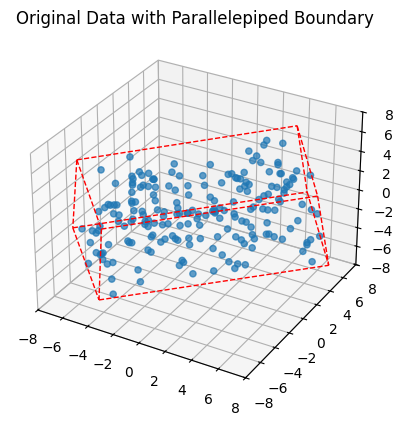

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection

# Define the parallelepiped generation function
def generate_points_in_parallelepiped(center, eigvecs, eigvals, scale_factor, n_points=200):
    # Uniform random coefficients in [-1,1]
    coeffs = np.random.uniform(-1, 1, size=(n_points, 3))
    # Scale by sqrt eigenvalues and scale factor
    scaled = coeffs * (np.sqrt(eigvals) * scale_factor)
    # Apply eigenvector matrix rotation and translation by center
    points = scaled @ eigvecs.T + center
    return points

# Define parallelepiped vertices from corners in coefficient space
def get_parallelepiped_vertices(center, eigvecs, eigvals, scale_factor):
    corners = np.array([[ 1, 1, 1],
                        [ 1, 1,-1],
                        [ 1,-1, 1],
                        [ 1,-1,-1],
                        [-1, 1, 1],
                        [-1, 1,-1],
                        [-1,-1, 1],
                        [-1,-1,-1]])
    scaled_corners = corners * (np.sqrt(eigvals) * scale_factor)
    vertices = scaled_corners @ eigvecs.T + center
    return vertices

# Parameters
center = np.array([0, 0, 0])
covariance = np.array([[3, 1, 0.5], [1, 2, 0.3], [0.5, 0.3, 1]])
eigvals, eigvecs = np.linalg.eigh(covariance)
scale_factor = 4

# Generate points inside the parallelepiped
points = generate_points_in_parallelepiped(center, eigvecs, eigvals, scale_factor, n_points=200)

# Get vertices of the parallelepiped
vertices = get_parallelepiped_vertices(center, eigvecs, eigvals, scale_factor)

# Edges between vertices to plot
edges_idx = [(0,1),(0,2),(0,4),(1,3),(1,5),(2,3),(2,6),(3,7),
             (4,5),(4,6),(5,7),(6,7)]

# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:,0], points[:,1], points[:,2], alpha=0.7)

# Construct lines for edges
lines = [(vertices[start], vertices[end]) for start,end in edges_idx]
lc = Line3DCollection(lines, colors='red', linewidths=1, linestyles='dashed')
ax.add_collection(lc)

ax.set_title("Original Data with Parallelepiped Boundary")
ax.set_xlim(-8,8)
ax.set_ylim(-8,8)
ax.set_zlim(-8,8)
plt.show()


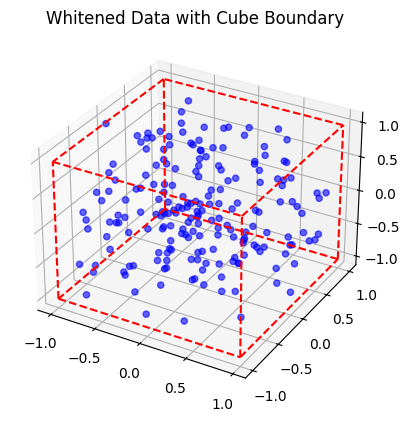

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection

# Generate whitened data points uniformly inside a cube [-1, 1]^3
cube_points = np.random.uniform(low=-1, high=1, size=(200, 3))

# Compute boundary limits from points to fit a tight cube
min_val = np.min(cube_points)
max_val = np.max(cube_points)
half_side = max(abs(min_val), abs(max_val))

# Define vertices of cube boundary around data points
vertices = np.array([[-half_side, -half_side, -half_side],
                     [ half_side, -half_side, -half_side],
                     [ half_side,  half_side, -half_side],
                     [-half_side,  half_side, -half_side],
                     [-half_side, -half_side,  half_side],
                     [ half_side, -half_side,  half_side],
                     [ half_side,  half_side,  half_side],
                     [-half_side,  half_side,  half_side]], dtype=float)

# Edges of the cube to draw
edges_idx = [(0,1),(1,2),(2,3),(3,0),
             (4,5),(5,6),(6,7),(7,4),
             (0,4),(1,5),(2,6),(3,7)]

# Create plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot points
ax.scatter(cube_points[:,0], cube_points[:,1], cube_points[:,2], color='blue', alpha=0.6, s=20)

# Plot cube edges
lines = [(vertices[start], vertices[end]) for start,end in edges_idx]
lc = Line3DCollection(lines, colors='red', linewidths=1.5, linestyles='dashed')
ax.add_collection(lc)

ax.set_title('Whitened Data with Cube Boundary')

# Set equal aspect ratio helper function
def set_axes_equal(ax):
    '''Set 3D plot axes to equal scale.'''
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    x_middle = np.mean(x_limits)
    y_range = abs(y_limits[1] - y_limits[0])
    y_middle = np.mean(y_limits)
    z_range = abs(z_limits[1] - z_limits[0])
    z_middle = np.mean(z_limits)

    plot_radius = 0.5 * max([x_range, y_range, z_range])

    ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
    ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
    ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])

# Apply equal axis scaling
set_axes_equal(ax)

plt.show()


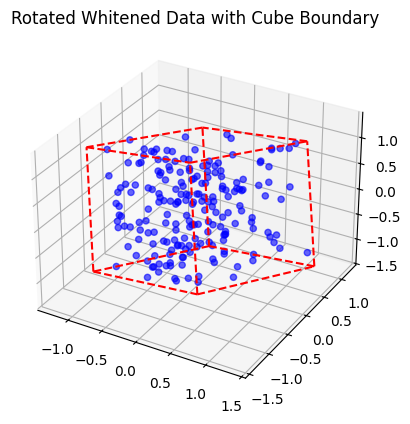

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection

def rodrigues_rotation_matrix(axis, theta):
    """
    Compute the rotation matrix using Rodrigues' formula.
    axis: 3-element array to rotate about (should be unit vector)
    theta: rotation angle in radians
    """
    axis = axis / np.linalg.norm(axis)
    a = np.cos(theta / 2.0)
    b, c, d = -axis * np.sin(theta / 2.0)

    R = np.array([[a*a + b*b - c*c - d*d,
                   2*(b*c - a*d),
                   2*(b*d + a*c)],
                  [2*(b*c + a*d),
                   a*a + c*c - b*b - d*d,
                   2*(c*d - a*b)],
                  [2*(b*d - a*c),
                   2*(c*d + a*b),
                   a*a + d*d - b*b - c*c]])
    return R

# Generate whitened data points uniformly inside a cube [-1, 1]^3
cube_points = np.random.uniform(low=-1, high=1, size=(200, 3))

# Compute boundary limits and half side length
min_val = np.min(cube_points)
max_val = np.max(cube_points)
half_side = max(abs(min_val), abs(max_val))

# Define vertices of the cube boundary (centered at origin)
vertices = np.array([[-half_side, -half_side, -half_side],
                     [ half_side, -half_side, -half_side],
                     [ half_side,  half_side, -half_side],
                     [-half_side,  half_side, -half_side],
                     [-half_side, -half_side,  half_side],
                     [ half_side, -half_side,  half_side],
                     [ half_side,  half_side,  half_side],
                     [-half_side,  half_side,  half_side]], dtype=float)

# Define edges of the cube
edges_idx = [(0,1),(1,2),(2,3),(3,0),
             (4,5),(5,6),(6,7),(7,4),
             (0,4),(1,5),(2,6),(3,7)]

# Rotation parameters
rotation_axis = np.array([1, 1, 1])  # Diagonal axis through opposite vertices
rotation_axis = rotation_axis / np.linalg.norm(rotation_axis)  # normalize
theta = np.radians(30)  # rotate 30 degrees

# Compute rotation matrix
R = rodrigues_rotation_matrix(rotation_axis, theta)

# Rotate vertices and points
rotated_vertices = (R @ vertices.T).T
rotated_points = (R @ cube_points.T).T

# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Scatter rotated points
ax.scatter(rotated_points[:,0], rotated_points[:,1], rotated_points[:,2], color='blue', alpha=0.6, s=20)

# Draw rotated cube edges
lines = [(rotated_vertices[start], rotated_vertices[end]) for start,end in edges_idx]
lc = Line3DCollection(lines, colors='red', linewidths=1.5, linestyles='dashed')
ax.add_collection(lc)

ax.set_title('Rotated Whitened Data with Cube Boundary')

# Set equal aspect ratio helper function
def set_axes_equal(ax):
    '''Set 3D plot axes to equal scale.'''
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    x_middle = np.mean(x_limits)
    y_range = abs(y_limits[1] - y_limits[0])
    y_middle = np.mean(y_limits)
    z_range = abs(z_limits[1] - z_limits[0])
    z_middle = np.mean(z_limits)

    plot_radius = 0.5 * max([x_range, y_range, z_range])

    ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
    ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
    ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])

# Apply equal axis scaling
set_axes_equal(ax)

plt.show()
